<a href="https://colab.research.google.com/github/salsilsulselsol/-EcoLedger-Immutable-Carbon-Tracker-/blob/main/05_Model_Building_and_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Building and Evaluation

**Objective:**
* Implement deep learning models using TensorFlow/Keras.
* Construct traditional machine learning models (Decision Tree, K-Means).
* Evaluate model performance using advanced metrics and visualization techniques (Confusion Matrix Heatmaps).

In [1]:
# Import global libraries for data manipulation, machine learning, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, silhouette_score
)

# Import TensorFlow for Neural Network implementation
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')

print('Global libraries imported successfully.')

Global libraries imported successfully.


## 1. Neural Network (Binary Classification)
**Technique:** Multi-Layer Perceptron (TensorFlow/Keras)
**Evaluation:** Binary Crossentropy, Accuracy, Confusion Matrix Heatmap

### Step 1: Data Preparation
Load the Breast Cancer dataset suitable for binary classification. Split the data and apply feature scaling, which is highly critical for Neural Network convergence.

In [2]:
# Load dataset
cancer_data = datasets.load_breast_cancer()
X_nn = cancer_data.data
y_nn = cancer_data.target

# Split into training (80%) and testing (20%) sets
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_nn, y_nn, test_size=0.2, random_state=42
)

# Standardize features for Neural Network optimization
scaler_nn = StandardScaler()
X_train_nn_scaled = scaler_nn.fit_transform(X_train_nn)
X_test_nn_scaled = scaler_nn.transform(X_test_nn)

print(f"Training data shape: {X_train_nn_scaled.shape}")
print(f"Testing data shape: {X_test_nn_scaled.shape}")

Training data shape: (455, 30)
Testing data shape: (114, 30)


### Step 2: Model Training
Define a sequential neural network architecture with hidden layers utilizing ReLU activation, and an output layer utilizing Sigmoid for binary prediction.

In [3]:
# Define the Neural Network architecture
nn_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_nn_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model defining optimizer, loss function, and tracking metrics
nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model silently (verbose=0) to maintain clean notebook output
history_nn = nn_model.fit(
    X_train_nn_scaled, y_train_nn,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

print("Neural Network training completed.")

Neural Network training completed.


--- Neural Network Evaluation ---
              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



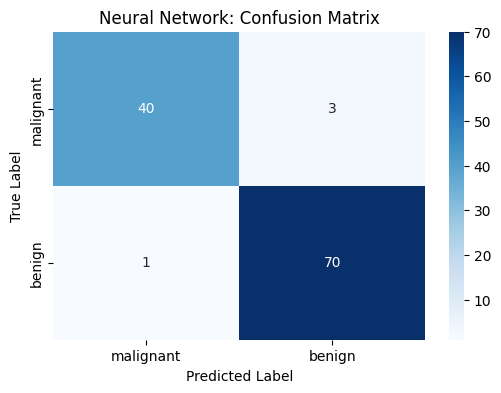

In [4]:
# Generate predictions (output is probability due to sigmoid, threshold at 0.5)
y_pred_prob_nn = nn_model.predict(X_test_nn_scaled, verbose=0)
y_pred_nn = (y_pred_prob_nn > 0.5).astype(int).flatten()

# Print evaluation metrics
print("--- Neural Network Evaluation ---")
print(classification_report(y_test_nn, y_pred_nn, target_names=cancer_data.target_names))

# Visualize Confusion Matrix
cm_nn = confusion_matrix(y_test_nn, y_pred_nn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer_data.target_names,
            yticklabels=cancer_data.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Neural Network: Confusion Matrix')
plt.show()

## 2. Decision Tree Classification
**Technique:** DecisionTreeClassifier (Scikit-Learn)
**Evaluation:** Accuracy, Classification Report

### Step 1: Data Preparation
Load the Iris dataset for multi-class classification.

In [6]:
# Load multi-class dataset
iris_data = datasets.load_iris()
X_dt = iris_data.data
y_dt = iris_data.target

# Split the dataset
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt, y_dt, test_size=0.2, random_state=42
)

print(f"Iris data loaded. Training samples: {len(X_train_dt)}")

Iris data loaded. Training samples: 120


### Step 2: Model Training
Initialize and train the Decision Tree without deep pruning for baseline performance.

In [7]:
# Initialize and fit the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_dt, y_train_dt)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


### Step 3: Evaluation and Visualization
Evaluate the Decision Tree against the test set and display the metric reports.

In [8]:
# Predict using the test set
y_pred_dt = dt_model.predict(X_test_dt)

# Evaluate metrics
accuracy_dt = accuracy_score(y_test_dt, y_pred_dt)
print("--- Decision Tree Evaluation ---")
print(f"Accuracy: {accuracy_dt:.4f}\n")
print("Classification Report:")
print(classification_report(y_test_dt, y_pred_dt, target_names=iris_data.target_names))

--- Decision Tree Evaluation ---
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 3. K-Means Clustering
**Technique:** K-Means (Unsupervised Learning)
**Evaluation:** Cluster Centroids, Silhouette Score

### Step 1: Data Preparation
Load the Wine dataset and remove the target labels to simulate an unsupervised learning scenario. Apply standard scaling.

In [9]:
# Load Wine dataset
wine_data = datasets.load_wine()
X_km_raw = wine_data.data

# Standardize features to balance distance calculations
scaler_km = StandardScaler()
X_km_scaled = scaler_km.fit_transform(X_km_raw)

print(f"Unsupervised data prepared and scaled. Shape: {X_km_scaled.shape}")

Unsupervised data prepared and scaled. Shape: (178, 13)


### Step 2: Model Training
Initialize K-Means with an assumed 3 clusters based on prior exploratory data analysis.

In [10]:
# Initialize and fit K-Means model
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans_model.fit_predict(X_km_scaled)

# Extract centroids
centroids = kmeans_model.cluster_centers_

print("K-Means clustering completed.")

K-Means clustering completed.


### Step 3: Evaluation and Visualization
Calculate the internal validation metric (Silhouette Score) and plot the cluster distribution on a 2D plane using the first two principal features.

--- K-Means Evaluation ---
Silhouette Score: 0.2849


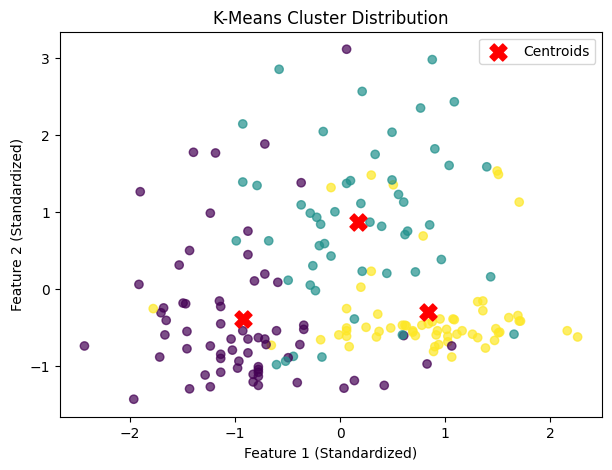

In [11]:
# Calculate internal clustering metric
sil_score = silhouette_score(X_km_scaled, cluster_labels)

print("--- K-Means Evaluation ---")
print(f"Silhouette Score: {sil_score:.4f}")

# Visualize the clusters using the first two features (Alcohol vs. Malic Acid)
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_km_scaled[:, 0], X_km_scaled[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=150, label='Centroids')

plt.xlabel('Feature 1 (Standardized)')
plt.ylabel('Feature 2 (Standardized)')
plt.title('K-Means Cluster Distribution')
plt.legend()
plt.show()